In [2]:
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Load in Data

* Range of data: 1/1/2022 to 3/22/2024
* Train/validation range: 1/1/2022 to 1/14/2023
    * 0.8/0.2 random train-validation split
* Test range: 1/15/2024-3/22/2024

In [3]:
data = pd.read_csv("data.csv")

In [4]:
train = data.loc[:71423]
train.head(3)

,Unnamed: 0,date,time,power,workday
0,0,2022-01-01,0.00,0.0,0
1,1,2022-01-01,0.25,0.0,0
2,2,2022-01-01,0.50,0.0,0


In [5]:
test = data.loc[71424:]
test.head(3)

,Unnamed: 0,date,time,power,workday
71424,71424,2024-01-15,0.00,-1.367699e-07,0
71425,71425,2024-01-15,0.25,-1.367699e-07,0
71426,71426,2024-01-15,0.50,-1.367699e-07,0


In [6]:
def get_X_y(df, lookahead):
    power = df['power'].to_numpy()
    workday = df['workday'].to_numpy()
    time = df['time'].to_numpy()
    
    power_chunks = [power[i:i+lookahead] for i in range(0, len(power) - lookahead, lookahead)]
    workday = [workday[i] for i in range(0, len(power) - lookahead, lookahead)]
    time = [time[i] for i in range(0, len(power) - lookahead, lookahead)]
    
    y = [power[i:i+lookahead] for i in range(lookahead, len(power), lookahead)]

    X = pd.DataFrame(data={"power" : power_chunks, "workday" : workday, "time" : time})
    y = pd.DataFrame(data={"power" : y})

    X = X.reset_index()
    y = y.reset_index()

    return X, y

In [7]:
LOOKAHEAD = 16

X_trainval, y_trainval = get_X_y(train, LOOKAHEAD)
X_test, y_test = get_X_y(test, LOOKAHEAD)

In [31]:
#[y for y in y_train['power']]

# Tuning K with Validation Set

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import numpy as np

# Assuming X_trainval and y_trainval are your original feature and target matrices

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

# Reduce dimensionality using PCA
pca = PCA(n_components=8)

X_train_matrix = np.array([a.flatten() for a in X_train['power'].to_numpy()]).reshape(len(X_train),16) 
X_train_matrix = pca.fit_transform(X_train_matrix)

X_val_matrix = np.array([a.flatten() for a in X_val['power'].to_numpy()]).reshape(len(X_val),16) 
X_val_matrix = pca.transform(X_val_matrix)

y_train_matrix = np.array([a.flatten() for a in y_train['power'].to_numpy()]).reshape(len(X_train),16) 

y_val_matrix = np.array([a.flatten() for a in y_val['power'].to_numpy()]).reshape(len(X_val),16) 


mses = []
wmses = []

alpha = 0.2

# Iterate over different values of k
for k in range(1, 21):
    models = {}
    # Train multiple k-NN regression models with different subsets of the training data
    for t in [0, 4, 8, 12, 16, 20]:
        for w in [0, 1]:
            knn_regressor = KNeighborsRegressor(n_neighbors=k)
            mask = (X_train['time'] == t) & (X_train['workday'] == w)
            X_input = X_train_matrix[mask]  # Using PCA-reduced features
            y_input = y_train_matrix[mask]
            knn_regressor.fit(X_input, y_input)
            models[(t, w)] = knn_regressor

    # Make predictions on the validation set using the trained models
    forecasts = []
    idx = 0
    for index, row in X_val.iterrows():
        forecasts.append(models[(row['time'], row['workday'])].predict(X_val_matrix[idx, :].reshape(1, -1)))
        idx += 1

    forecast = np.array([f[0] for f in forecasts]).flatten()
    real = y_val_matrix.flatten()

    # Calculate MSE and WMSE
    mse = mean_squared_error(forecast, real)
    weights = alpha ** (1 + np.sign(forecast - real))
    wmse = mean_squared_error(forecast, real, sample_weight=weights)

    mses.append(mse)
    wmses.append(wmse)
    
    # Print results
    print(f"k={k}\tMSE={mse}\tWMSE={wmse}")


k=1	MSE=30.266103041057313	WMSE=36.77624450709372
k=2	MSE=22.108673015148057	WMSE=30.0389402071875
k=3	MSE=19.124660994660317	WMSE=27.239117817520185
k=4	MSE=18.008156295609076	WMSE=27.5827329408993
k=5	MSE=17.778380703021114	WMSE=28.73914043870744
k=6	MSE=18.036064644443783	WMSE=29.307832100364294
k=7	MSE=18.07345446480856	WMSE=30.215672440974483
k=8	MSE=17.976307559154222	WMSE=30.138282756720972
k=9	MSE=17.904243939146905	WMSE=31.03583532044522
k=10	MSE=17.746740203059726	WMSE=31.413511124392244
k=11	MSE=17.77138940321325	WMSE=31.70820788381975
k=12	MSE=17.61707298327062	WMSE=31.688514155452566
k=13	MSE=17.52685372610717	WMSE=31.692222961271206
k=14	MSE=17.60494012732628	WMSE=31.61987502231036
k=15	MSE=17.631481773157873	WMSE=32.44916976309288
k=16	MSE=17.59417120081643	WMSE=32.27593026418609
k=17	MSE=17.431152508239215	WMSE=32.06088570906408
k=18	MSE=17.453758299883255	WMSE=32.58913318941047
k=19	MSE=17.42120586867604	WMSE=32.527149914484575
k=20	MSE=17.53650567003315	WMSE=33.025640

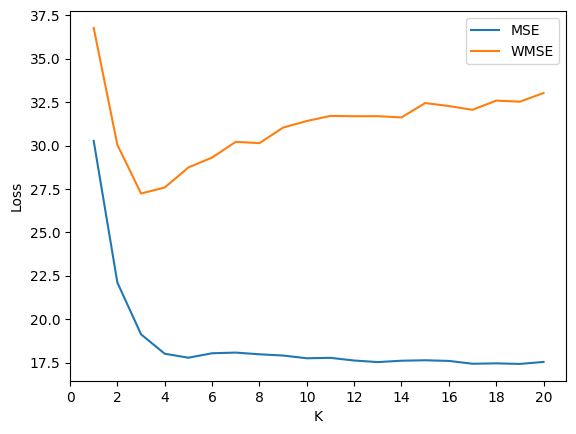

In [44]:
plt.plot(range(1, 21), mses, label="MSE")
plt.plot(range(1, 21), wmses, label="WMSE")
plt.legend()
plt.xlabel("K")
plt.xticks(range(0, 21, 2))
plt.ylabel("Loss");

# Final Model
* k = 3
* Train with all data between 1/1/2022 and 1/14/2024
* Test with data between 1/15/2024 and 3/22/2024

In [58]:
models = {}


for t in [0, 4, 8, 12, 16, 20]:
    for w in [0, 1]:
        knn_regressor = KNeighborsRegressor(n_neighbors=4)
        mask = (X_train['time'] == t) & (X_train['workday'] == w)
        X_input = X_train_matrix[mask]  # Using PCA-reduced features
        y_input = y_train_matrix[mask]
        knn_regressor.fit(X_input, y_input)
        models[(t, w)] = knn_regressor

In [59]:
X_test_matrix = np.array([a.flatten() for a in X_test['power'].to_numpy()]).reshape(len(X_test),16) 
X_test_matrix = pca.transform(X_test_matrix)

y_test_matrix = np.array([a.flatten() for a in y_test['power'].to_numpy()]).reshape(len(X_test),16) 

# Make predictions on the validation set using the trained models
forecasts = []
idx = 0
for index, row in X_test.iterrows():
    forecasts.append(models[(row['time'], row['workday'])].predict(X_test_matrix[idx, :].reshape(1, -1)))
    idx += 1

forecast = np.array([f[0] for f in forecasts]).flatten()
real = y_test_matrix.flatten()

mse = mean_squared_error(forecast, real)

weights = alpha ** (1 + np.sign(forecast - real))
wmse = mean_squared_error(forecast, real, sample_weight=weights)

print(f"MSE={mse}\tWMSE={wmse}")

MSE=27.014457009631727	WMSE=40.98595287288319


# Sanity Check

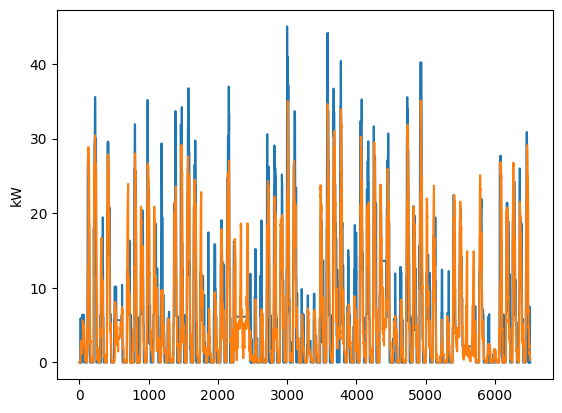

In [54]:
all_forecast = np.array([f[0] for f in forecasts]).flatten()
all_real = np.array([a for a in y_test['power'].to_numpy()]).flatten()

plt.plot(real, label="Actual")
plt.plot(forecast, label="Forecast")
plt.ylabel("kW");